In [9]:
!pip -q install ucimlrepo
import pandas as pd
from ucimlrepo import fetch_ucirepo

In [10]:
bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features.copy()
y = bank_marketing.data.targets.copy()

print(X.shape)
print(y.shape)

(45211, 16)
(45211, 1)


In [11]:
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


In [12]:
y.head()

,y
0,no
1,no
2,no
3,no
4,no


In [13]:
y.value_counts()

,count
y,
no,39922
yes,5289


In [15]:
y = y["y"].map({"no": 0, "yes": 1})
print(y.head())
print(y.value_counts())

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64
y
0    39922
1     5289
Name: count, dtype: int64


In [16]:
print("Text columns:")
print(X.select_dtypes(include="object").columns)

print("\nNumber columns:")
print(X.select_dtypes(exclude="object").columns)

Text columns:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

Number columns:
Index(['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous'],
      dtype='object')


In [17]:
print(X.isnull().sum().sort_values(ascending=False))

poutcome       36959
contact        13020
education       1857
job              288
default            0
balance            0
age                0
marital            0
loan               0
housing            0
month              0
day_of_week        0
duration           0
campaign           0
pdays              0
previous           0
dtype: int64


In [18]:
(X.isnull().mean() * 100).sort_values(ascending=False)

,0
poutcome,81.747805
contact,28.798301
education,4.107407
job,0.637013
default,0.000000
balance,0.000000
age,0.000000
marital,0.000000
loan,0.000000
housing,0.000000


In [19]:
X = X.drop(columns=["poutcome"])
print(X.shape)
print(X.columns)

(45211, 15)
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign',
       'pdays', 'previous'],
      dtype='object')


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (36168, 15)
X_test: (9043, 15)
y_train: (36168,)
y_test: (9043,)


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_cols = X_train.select_dtypes(exclude="object").columns.tolist()
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("Preprocessor is ready ✅")

Preprocessor is ready ✅


In [22]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model.fit(X_train, y_train)

print("Model training completed ✅")

Model training completed ✅


In [23]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 1 0 0]


In [24]:
print("Predicted:", y_pred[:10])
print("Actual:   ", y_test.iloc[:10].values)

Predicted: [0 0 0 0 0 0 0 1 0 0]
Actual:    [0 0 0 0 0 0 0 1 0 0]


In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8220723211323676


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[6601 1384]
 [ 225  833]]


In [27]:
833 / (833 + 225)

0.7873345935727788

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.83      0.89      7985
           1       0.38      0.79      0.51      1058

    accuracy                           0.82      9043
   macro avg       0.67      0.81      0.70      9043
weighted avg       0.90      0.82      0.85      9043



In [29]:
y_proba = model.predict_proba(X_test)[:, 1]

y_pred_07 = (y_proba >= 0.7).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_07))
print(classification_report(y_test, y_pred_07))

[[7279  706]
 [ 411  647]]
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      7985
           1       0.48      0.61      0.54      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.76      0.73      9043
weighted avg       0.89      0.88      0.88      9043



In [32]:
y_pred_08 = (y_proba >= 0.8).astype(int)

print(confusion_matrix(y_test, y_pred_08))
print(classification_report(y_test, y_pred_08))

[[7526  459]
 [ 548  510]]
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7985
           1       0.53      0.48      0.50      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.71      0.72      9043
weighted avg       0.88      0.89      0.89      9043



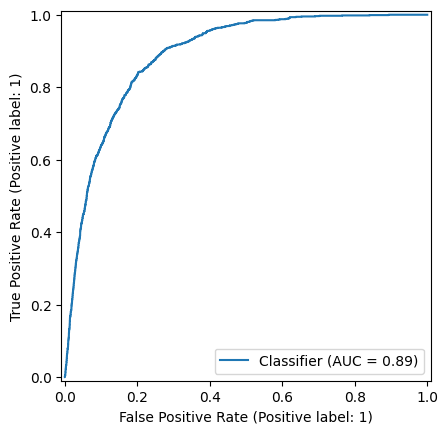

In [33]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba)

# Marketing Campaign Response Prediction

This project uses the UCI Bank Marketing dataset to predict whether a customer will respond positively to a marketing campaign.

## Project goal

The goal of this project is to build a machine learning model that predicts whether a customer will say yes or no to a marketing campaign offer.

## Dataset

The dataset used in this project is the UCI Bank Marketing dataset. It contains customer information and campaign-related variables.

## Data preparation

The target variable was converted from text labels (yes/no) into numeric labels (1/0).  
Missing values were checked, and the `poutcome` column was removed because it contained a very high percentage of missing data.  
The dataset was then split into training and testing sets.

## Model

A logistic regression model was used as the baseline model.  
Numerical variables were scaled, categorical variables were one-hot encoded, and missing values were handled using a preprocessing pipeline.

## Results

The baseline model achieved an accuracy of about 82%.  
The ROC-AUC score was about 0.89, showing good class separation.  

Threshold tuning was also tested:
- At 0.5, recall for the positive class was higher.
- At 0.7, the model gave a more balanced trade-off.
- At 0.8, precision improved further, but recall decreased.

## Conclusion

This project showed how machine learning can be used to predict customer campaign responses.  
The results also showed the trade-off between precision and recall when changing the decision threshold.  
For this project, a threshold of 0.7 provided a more balanced result than 0.5 or 0.8.